# Assignment: Pandas Groupby with Hurricane Data

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

url = 'https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r00/access/csv/ibtracs.ALL.list.v04r00.csv'
df = pd.read_csv(url, parse_dates=['ISO_TIME'], usecols=range(12),
                 skiprows=[1], na_values=[' ', 'NOT_NAMED'],
                 keep_default_na=False, dtype={'NAME': str})
df.tail()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WMO_WIND,WMO_PRES
716160,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 06:00:00,NR,23.0325,89.3509,NaN,NaN
716161,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 09:00:00,NR,23.3337,89.6178,NaN,NaN
716162,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 12:00:00,NR,23.6263,89.8799,NaN,NaN
716163,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 15:00:00,NR,23.9143,90.1400,NaN,NaN
716164,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 18:00:00,NR,24.2000,90.4000,NaN,NaN


### How many rows does this dataset have?

In [2]:
len(df)

716165

### How many North Atlantic hurricanes are in this dataset?

In [3]:
len(df[df['BASIN'] == 'NA'])

126392

## 1) Get the unique values of the `BASIN`, `SUBBASIN`, and `NATURE` columns

In [4]:
df['BASIN'].unique()

array(['NI', 'SI', 'NA', 'EP', 'WP', 'SP', 'SA'], dtype=object)

In [5]:
df['SUBBASIN'].unique()

array(['BB', 'AS', 'MM', 'GM', 'NA', 'CS', 'WA', 'EA', 'CP'], dtype=object)

In [6]:
df['NATURE'].unique()

array(['NR', 'TS', 'ET', 'SS', 'MX', 'DS'], dtype=object)

## 2) Rename the `WMO_WIND` and `WMO_PRES` columns to `WIND` and `PRES`

In [7]:
df = df.rename(columns={'WMO_WIND': 'WIND', 'WMO_PRES': 'PRES'})
df.head()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WIND,PRES
0,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 03:00:00,NR,10.9000,80.3000,NaN,NaN
1,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 06:00:00,NR,10.8709,79.8265,NaN,NaN
2,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 09:00:00,NR,10.8431,79.3524,NaN,NaN
3,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 12:00:00,NR,10.8188,78.8772,NaN,NaN
4,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 15:00:00,NR,10.8000,78.4000,NaN,NaN


## 3) Get the 10 largest rows in the dataset by `WIND`

In [8]:
df.nlargest(10, 'WIND')

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WIND,PRES
666142,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 12:00:00,TS,17.3,-105.6,185.0,872.0
666140,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 06:00:00,TS,16.5,-105.4,180.0,886.0
666144,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 18:00:00,TS,18.3,-105.3,180.0,878.0
427655,1980214N11330,1980,57,NA,GM,ALLEN,1980-08-07 18:00:00,TS,21.8,-86.4,165.0,899.0
178210,1935241N23291,1935,46,NA,NA,NaN,1935-09-03 00:00:00,TS,24.6,-80.5,160.0,892.0
178211,1935241N23291,1935,46,NA,NA,NaN,1935-09-03 02:00:00,TS,24.8,-80.8,160.0,892.0
178213,1935241N23291,1935,46,NA,GM,NaN,1935-09-03 06:00:00,TS,25.1,-81.1,160.0,NaN
482093,1988253N12306,1988,74,NA,CS,GILBERT,1988-09-14 00:00:00,TS,19.7,-83.8,160.0,888.0
552477,1997253N12255,1997,81,EP,MM,LINDA,1997-09-12 06:00:00,TS,17.1,-109.6,160.0,902.0
605764,2005289N18282,2005,97,NA,CS,WILMA,2005-10-19 12:00:00,TS,17.3,-82.8,160.0,882.0


## 4) Group the data on `SID` and get the 10 largest hurricanes by `WIND`

In [9]:
gb = df.groupby('SID')
gb['WIND'].aggregate('max').nlargest(10)

SID
2015293N13266    185.0
1980214N11330    165.0
1935241N23291    160.0
1988253N12306    160.0
1997253N12255    160.0
2005289N18282    160.0
2019236N10314    160.0
1998295N12284    155.0
2005261N21290    155.0
2009288N07267    155.0
Name: WIND, dtype: float64

In [10]:
df.groupby(['SID', 'NAME'])['WIND'].max().nlargest(10)

SID            NAME    
2015293N13266  PATRICIA    185.0
1980214N11330  ALLEN       165.0
1988253N12306  GILBERT     160.0
1997253N12255  LINDA       160.0
2005289N18282  WILMA       160.0
2019236N10314  DORIAN      160.0
1998295N12284  MITCH       155.0
2005261N21290  RITA        155.0
2009288N07267  RICK        155.0
2017242N16333  IRMA        155.0
Name: WIND, dtype: float64

## 5) Make a bar chart of the wind speed of the 20 strongest-wind hurricanes

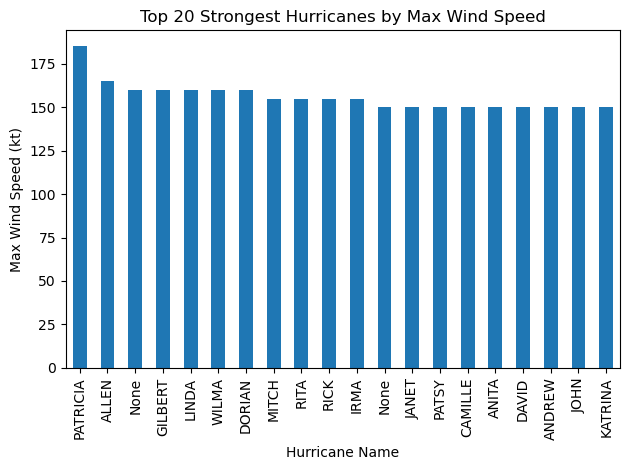

In [11]:
max_wind = gb['WIND'].aggregate('max')
names = df.groupby('SID')['NAME'].aggregate('first')

top20 = max_wind.nlargest(20)
top20.index = names[top20.index].values

top20.plot(kind='bar')
plt.ylabel('Max Wind Speed (kt)')
plt.xlabel('Hurricane Name')
plt.title('Top 20 Strongest Hurricanes by Max Wind Speed')
plt.tight_layout()

## 6) Plot the count of all datapoints by Basin

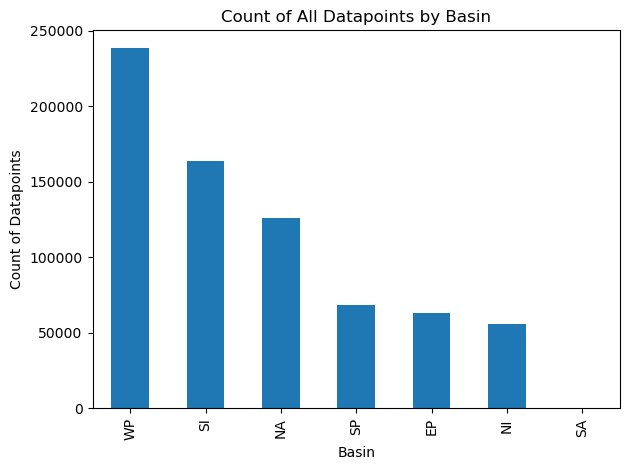

In [12]:
df.groupby('BASIN')['SID'].size().sort_values(ascending = False).plot(kind='bar')
plt.ylabel('Count of Datapoints')
plt.xlabel('Basin')
plt.title('Count of All Datapoints by Basin')
plt.tight_layout()

## 7) Plot the count of unique hurricanes by Basin

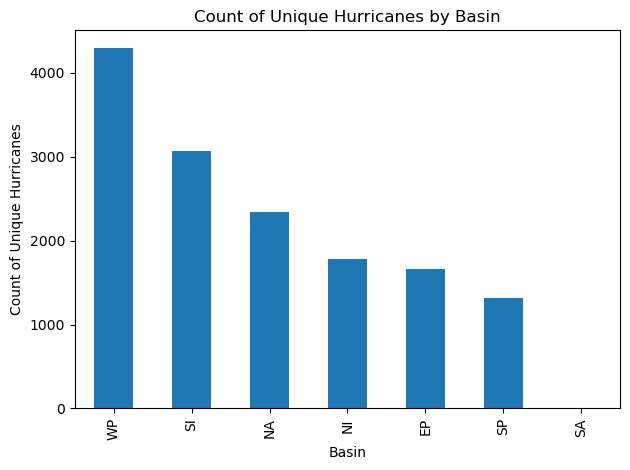

In [13]:
df.groupby('BASIN')['SID'].nunique().sort_values(ascending = False).plot(kind='bar')
plt.ylabel('Count of Unique Hurricanes')
plt.xlabel('Basin')
plt.title('Count of Unique Hurricanes by Basin')
plt.tight_layout()

## 8) Make a `hexbin` of the location of datapoints in Latitude and Longitude

<Axes: title={'center': 'Hexbin of Hurricane Datapoint Locations'}, xlabel='LON', ylabel='LAT'>

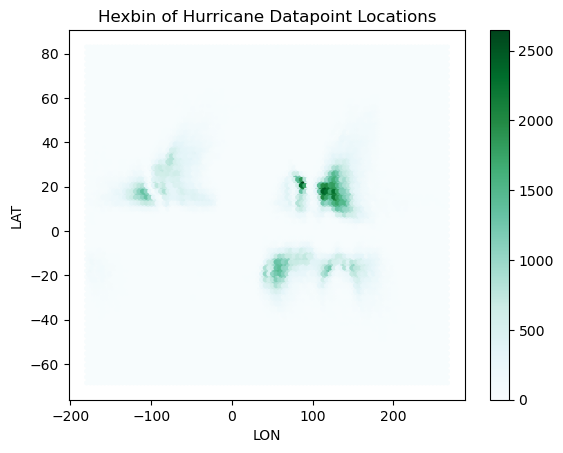

In [14]:
df.plot.hexbin(x="LON", y="LAT", title='Hexbin of Hurricane Datapoint Locations')

## 9) Find Hurricane Katrina (from 2005) and plot its track as a scatter plot

In [15]:
df[(df['NAME'] == 'KATRINA') & (df['SEASON'] == 2005)][['SID', 'NAME', 'SEASON']].drop_duplicates()

,SID,NAME,SEASON
603763,2005236N23285,KATRINA,2005


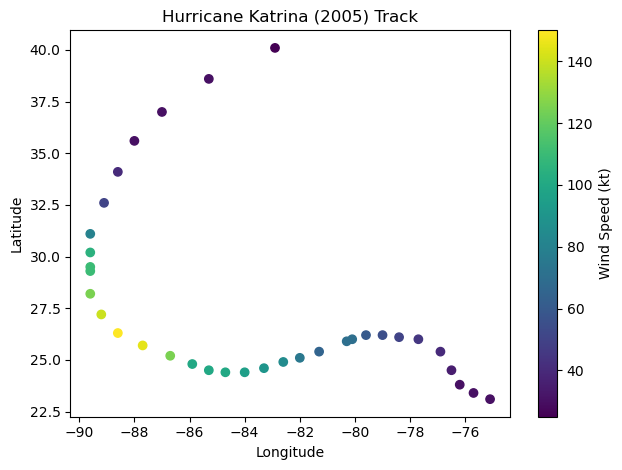

In [16]:
katrina_sid = '2005236N23285'
df_katrina = gb.get_group(katrina_sid)

plt.scatter(df_katrina['LON'], df_katrina['LAT'], c=df_katrina['WIND'])
plt.colorbar(label='Wind Speed (kt)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Hurricane Katrina (2005) Track')
plt.tight_layout()

## 10) Make time the index on your dataframe

In [17]:
df = df.set_index('ISO_TIME')
df.head()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,NATURE,LAT,LON,WIND,PRES
ISO_TIME,,,,,,,,,,,
1842-10-25 03:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.9000,80.3000,NaN,NaN
1842-10-25 06:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8709,79.8265,NaN,NaN
1842-10-25 09:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8431,79.3524,NaN,NaN
1842-10-25 12:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8188,78.8772,NaN,NaN
1842-10-25 15:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8000,78.4000,NaN,NaN


## 11) Plot the count of all datapoints per year as a timeseries

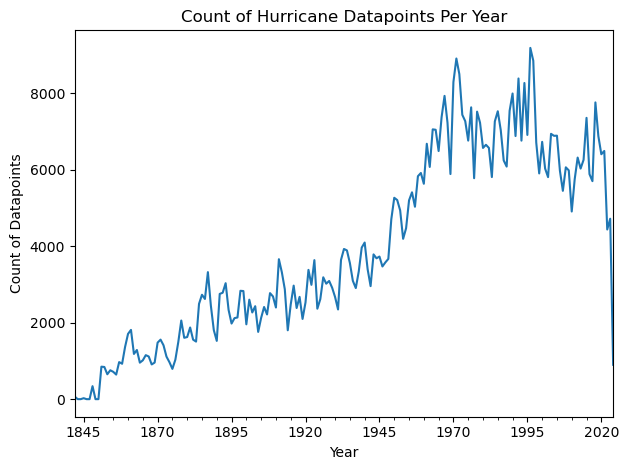

In [18]:
df.resample('YE').count()['SID'].plot()
plt.ylabel('Count of Datapoints')
plt.xlabel('Year')
plt.title('Count of Hurricane Datapoints Per Year')
plt.tight_layout()

In [19]:
df.resample('YE').size().nlargest(5)

ISO_TIME
1996-12-31    9189
1971-12-31    8911
1997-12-31    8854
1972-12-31    8503
1992-12-31    8389
dtype: int64

### Which years stand out as having anomalous hurricane activity?
1996 and 1971 stand out as having anomalously high hurricane activity, with datapoint counts exceeding 8900 for each year. More broadly, the years around 1970–2000 show consistently elevated activity compared to earlier decades. In contrast, several years in the 1840s have zero or near-zero datapoints recorded, which is likely due to incomplete observational coverage before the satellite era rather than a true absence of hurricane activity.